In [13]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = pd.read_csv("./scaled_df_2023.csv")

In [15]:
dataset.head(3)

,평균_지진옥외대피소_밀도,평균_자전거편의시설_밀도,평균_택시승차대_밀도,평균_작은도서관_밀도,평균_에코스쿨위치_밀도,평균_한파쉼터_밀도,평균_보행등_밀도,평균_CCTV_밀도,평균_불법주정차CCTV_밀도,평균_나눔카_밀도,...,cctv,안내표지판,노면표기,보안등,서비스안내판,위치신고안내판,기타시설물,범죄발생정도,Grid개수,범죄발생정도평균
0,0.547105,0.847404,0.045586,-1.473170,-0.139130,-0.630199,-0.659940,0.508896,0.879787,0.522481,...,0.173342,-0.494228,-0.677263,0.114016,-0.222950,-0.114310,-0.198591,6763.0,78.0,86.705128
1,-0.808405,1.880422,-0.668297,0.791987,-0.260421,0.493574,0.620399,-0.230978,-0.850916,1.274388,...,-0.833541,-0.672808,0.107947,0.030266,-0.222950,-0.229787,-0.609597,3398.0,50.0,67.960000
2,-0.953786,-0.602316,-0.516304,-0.604573,-0.614229,0.236263,-1.149218,-0.789743,-0.303606,-1.347587,...,1.635693,2.345199,3.048038,1.490588,-0.141493,3.245619,0.577755,2497.0,45.0,55.488889


In [17]:
dataset = dataset.drop(columns=['Grid개수'])
dataset = dataset.drop(columns=['범죄발생정도'])

In [19]:
dataset.head(3)

,평균_지진옥외대피소_밀도,평균_자전거편의시설_밀도,평균_택시승차대_밀도,평균_작은도서관_밀도,평균_에코스쿨위치_밀도,평균_한파쉼터_밀도,평균_보행등_밀도,평균_CCTV_밀도,평균_불법주정차CCTV_밀도,평균_나눔카_밀도,...,평균_공공와이파이_밀도,안심벨,cctv,안내표지판,노면표기,보안등,서비스안내판,위치신고안내판,기타시설물,범죄발생정도평균
0,0.547105,0.847404,0.045586,-1.473170,-0.139130,-0.630199,-0.659940,0.508896,0.879787,0.522481,...,-0.986753,0.492486,0.173342,-0.494228,-0.677263,0.114016,-0.222950,-0.114310,-0.198591,86.705128
1,-0.808405,1.880422,-0.668297,0.791987,-0.260421,0.493574,0.620399,-0.230978,-0.850916,1.274388,...,0.066371,-0.013395,-0.833541,-0.672808,0.107947,0.030266,-0.222950,-0.229787,-0.609597,67.960000
2,-0.953786,-0.602316,-0.516304,-0.604573,-0.614229,0.236263,-1.149218,-0.789743,-0.303606,-1.347587,...,-0.832779,1.689020,1.635693,2.345199,3.048038,1.490588,-0.141493,3.245619,0.577755,55.488889


In [36]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cols_mean1 = ['평균_공공와이파이_밀도','평균_한파쉼터_밀도','평균_무더위쉼터_밀도']

scaler = StandardScaler()
df_cols_scaled1 = scaler.fit_transform(dataset[cols_mean1])
pca1 = PCA(n_components=1)
pca1.fit(df_cols_scaled1)
print('PCA 컴포넘트 별 변동성', pca1.explained_variance_ratio_)

cols_mean2 = ['평균_따릉이대여소_밀도','평균_보행등_밀도']

df_cols_scaled2 = scaler.fit_transform(dataset[cols_mean2])
pca2 = PCA(n_components=1)
pca2.fit(df_cols_scaled2)
print('PCA 컴포넘트 별 변동성', pca2.explained_variance_ratio_)

cols_mean3 = ['평균_공영주차장_밀도','평균_불법주정차CCTV_밀도']

df_cols_scaled3 = scaler.fit_transform(dataset[cols_mean3])
pca3 = PCA(n_components=1)
pca3.fit(df_cols_scaled3)
print('PCA 컴포넘트 별 변동성', pca3.explained_variance_ratio_)

cols_mean4 = ['평균_CCTV_밀도','노면표기', '보안등','위치신고안내판']

df_cols_scaled4 = scaler.fit_transform(dataset[cols_mean4])
pca4 = PCA(n_components=1)
pca4.fit(df_cols_scaled4)
print('PCA 컴포넘트 별 변동성', pca3.explained_variance_ratio_)

PCA 컴포넘트 별 변동성 [0.79283719]
PCA 컴포넘트 별 변동성 [0.84342083]
PCA 컴포넘트 별 변동성 [0.78826298]
PCA 컴포넘트 별 변동성 [0.78826298]


In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm

pca1_component = pca1.fit_transform(df_cols_scaled1)
pca2_component = pca1.fit_transform(df_cols_scaled2)
pca3_component = pca1.fit_transform(df_cols_scaled3)
pca4_component = pca1.fit_transform(df_cols_scaled4)

dataset['와이+무더위+한파'] = pca1_component
dataset['따릉이+보행등'] = pca2_component
dataset['공주_불주'] = pca3_component
dataset['안심시설물+CCTV'] = pca4_component

# 회귀 분석
X_feature = dataset[['안심시설물+CCTV','와이+무더위+한파', '따릉이+보행등', '공주_불주','평균_지진옥외대피소_밀도','평균_자전거편의시설_밀도','평균_택시승차대_밀도','평균_작은도서관_밀도','평균_에코스쿨위치_밀도','평균_CCTV_밀도','평균_나눔카_밀도','평균_공중화장실_밀도','평균_공공아파트_밀도']]
y_label = dataset['범죄발생정도평균']

In [42]:
# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test=train_test_split(X_features, y_label,
                                         test_size=0.2, random_state=156 )

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val= train_test_split(X_train, y_train, test_size=0.1, random_state=156 )
print(X_train.shape , X_test.shape)
print(X_tr.shape, X_val.shape)

(20, 24) (5, 24)
(18, 24) (2, 24)


In [62]:
# 만약 구버전 XGBoost에서 DataFrame으로 DMatrix 생성이 안될 경우 X_train.values로 넘파이 변환.
# 학습, 검증, 테스트용 DMatrix를 생성.
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test , label=y_test)

In [166]:
params = { 'max_depth':3,
          'eta': 0.03,
          'objective':'reg:squarederror',
          'eval_metric':'rmse',
          'gamma':'0.5',
          'min_child_weight':'3'
         }
num_rounds = 350

In [168]:
# 학습 데이터 셋은 'train' 또는 평가 데이터 셋은 'eval' 로 명기합니다. 
eval_list = [(dtr,'train'),(dval,'eval')] # 또는 eval_list = [(dval,'eval')] 만 명기해도 무방. 

# 하이퍼 파라미터와 early stopping 파라미터를 train( ) 함수의 파라미터로 전달
xgb_model = xgb.train(params = params , dtrain=dtr , num_boost_round=num_rounds , \
                      early_stopping_rounds=50, evals=eval_list )

[0]	train-rmse:28.09260	eval-rmse:22.67599
[1]	train-rmse:27.71937	eval-rmse:22.82619
[2]	train-rmse:27.35840	eval-rmse:22.97314
[3]	train-rmse:27.00939	eval-rmse:23.11690
[4]	train-rmse:26.68561	eval-rmse:23.09365
[5]	train-rmse:26.35676	eval-rmse:23.22816
[6]	train-rmse:26.03907	eval-rmse:23.20465
[7]	train-rmse:25.73013	eval-rmse:23.33225
[8]	train-rmse:25.43185	eval-rmse:23.31146
[9]	train-rmse:25.14184	eval-rmse:23.43238
[10]	train-rmse:24.86674	eval-rmse:23.32980
[11]	train-rmse:24.58688	eval-rmse:22.69370
[12]	train-rmse:24.31466	eval-rmse:22.70475
[13]	train-rmse:24.05661	eval-rmse:22.62924
[14]	train-rmse:23.79343	eval-rmse:22.02609
[15]	train-rmse:23.53800	eval-rmse:22.03397
[16]	train-rmse:23.29585	eval-rmse:21.98447
[17]	train-rmse:23.05282	eval-rmse:21.98939
[18]	train-rmse:22.80849	eval-rmse:21.42569
[19]	train-rmse:22.58118	eval-rmse:21.40130
[20]	train-rmse:22.35308	eval-rmse:21.40318
[21]	train-rmse:22.12303	eval-rmse:20.87052
[22]	train-rmse:21.90931	eval-rmse:20.8700

In [170]:
pred_probs = xgb_model.predict(dtest)
print('predict( ) 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨')
print(np.round(pred_probs[:10],3))

# 예측 확률이 0.5 보다 크면 1 , 그렇지 않으면 0 으로 예측값 결정하여 List 객체인 preds에 저장 
preds = [ 1 if x > 0.5 else 0 for x in pred_probs ]
print('예측값 10개만 표시:',preds[:10])

predict( ) 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨
[ 75.69   76.508  69.943  67.827 110.523]
예측값 10개만 표시: [1, 1, 1, 1, 1]


In [172]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def get_reg_eval(y_test, pred=None):
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    print('평가 지표')
    print('MAE: {0:.4f}, MSE: {1:.4f}, RMSE: {2:.4f}, R^2: {3:.4f}'.format(mae, mse, rmse, r2))

In [174]:
# pred는 예측된 연속형 값
# y_test는 실제 연속형 값
get_reg_eval(y_test, preds)

평가 지표
MAE: 56.2458, MSE: 3460.3398, RMSE: 58.8247, R^2: -10.6609


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

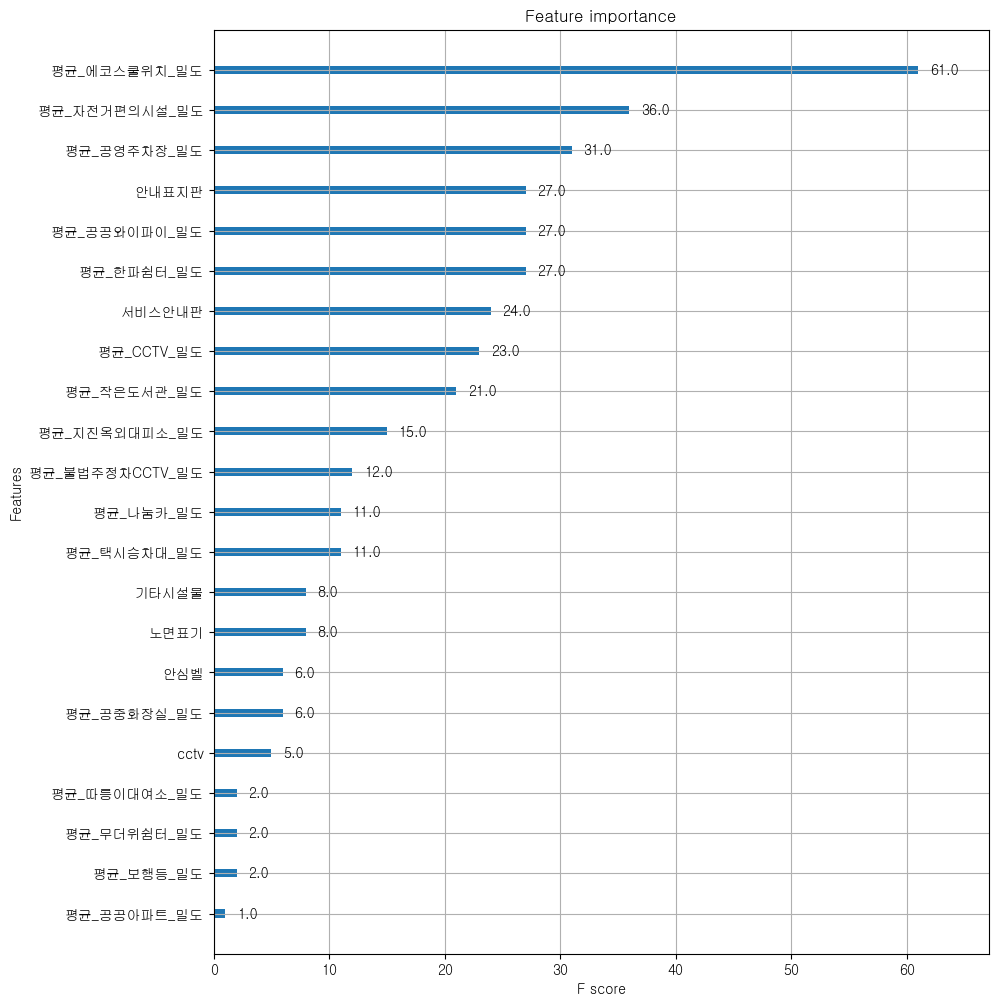

In [176]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

font_path = 'c:/WINDOWS/Fonts/GULIM.ttc'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_model, ax=ax)